# MDTF ESNB Notebook: North Atlantic Ocean POD

Author: Taydra Low \
Date: 05/27/26

* More details on the development process:
[MDTF Planning Document](https://docs.google.com/document/d/1P8HqL8O5304qwR3ik9RmgFDwSWwlkPgOjnp39PIkLfY/edit?usp=sharing)

* [ESNB GitHub Repository](https://github.com/jkrasting/esnb/tree/ncar-updates)

* To run this notebook, please set the correct kernel first. The commands to create a conda environment and make it accessible from Jupyter notebook (only need to do this once for each environment) are below:
```python
conda create -n esnb python=3.12
conda activate esnb
pip install esnb gcsfs
pip install ipykernel
python -m ipykernel install --user --name esnb
```

This notebook runs the `natl_ocean` POD (Maroon et al.) through the ESNB interface on CESM2 historical r1i1p1f1.

Validated end-to-end 2026-04-22 with:
- 2 yrs (1980–1981) of CESM2 monthly ocean data from `/glade/collections/cmip/CMIP6/…`
- Obs: `/glade/campaign/cgd/ccr/yeager/Sub2Sub/POD_data/obs_1x1.nc` (symlinked into `inputdata/obs_data/natl_ocean/`)

**Kernel:** `Python (esnb)` (set via the top-right kernel selector).

Note: Create a separate pdf that has directions on where to get this notebook (need to push to my github so the code can be copied from there)

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, copy, json
from pathlib import Path
import xarray as xr

os.environ['CODE_ROOT'] = '/glade/work/taydral/MDTF/MDTF-diagnostics'
os.environ['WORK_DIR']  = '/glade/work/taydral/MDTF/wkdir/MDTF_output/natl_ocean'
os.environ['OBS_DATA']  = '/glade/work/taydral/MDTF/inputdata/obs_data/natl_ocean/'
Path(os.environ['WORK_DIR']).mkdir(parents=True, exist_ok=True)

## About the POD: North Atlantic Ocean diagnostics

This POD evaluates how well climate models represent the subtropical-to-subpolar North Atlantic
ocean state, focusing on:
- Sea surface and upper-200m temperature and salinity climatologies
- Mixed layer depth (MLD)
- Potential density (σ₀)
- Surface heat and freshwater fluxes
- Surface-forced water-mass transformation (WMT) in σ₂ coordinates
- Atlantic Meridional Overturning Circulation (AMOC) streamfunction in σ₂ coordinates
- Bias relative to a 1°×1° observation-based reference (`obs_1x1.nc`)

------------------------------------------
- POD source: `diagnostics/natl_ocean/` (Maroon et al., adapted from `emaroon/cmip_input_noamoc` + `emaroon/separate_folders`)
- Helper module: `POD_utils.py` (bias, WMT, and AMOC analysis functions)
- AMOC code adapted from Sub2Sub's `moc_funcs.py` (Yeager, Maroon)
- Detailed description: `diagnostics/natl_ocean/doc/natl_ocean.rst`
-------------------------------------------

## Section 3: Diagnostics Computation (9 Steps)

**POD-specific logic**: This section contains all the physics calculations specific to the natl_ocean POD:

- **Steps 1-5**: Data preprocessing (σ₀, MLD, depth-averaging, regridding, climatology)
- **Steps 6-7**: Surface-forced water mass transformation analysis
- **Steps 8-9**: AMOC streamfunction computation

This logic is independent of the data source (CESM2, GFDL, or other models). The only requirement is that inputs are preprocessed coordinates and 3D fields.

All calculations use functions from `POD_utils.py`.

## Jupyter ESNB notebook POD settings
- This pod requires CMIP6 monthly ocean variables (tos, thetao, so, hfds, vsf, uo, vo) plus fx (areacello, volcello). Optional: umo, vmo for the mass-transport AMOC path.
The POD is built upon the following procedures:
### [Section 1: Prepare POD Settings](#section1)
- Set the parameters of the POD (interactive or read from `settings.jsonc`)
- Set the runtime configurations (machine, dask cluster size)
- Define the model case (CESM2 historical r1i1p1f1) and date range
- Point at the data catalog and obs / work directories
### [Section 2: Load Data from Catalog Files](#section2)
- ESNB load for the monthly variables (auto-skips optional umo/vmo if not in catalog)
- Manual `xr.open_dataset` for fx (time-invariant) variables
- Per-variable dispatch into named datasets (`ds_thetao`, `ds_so`, `ds_uo`, `ds_vo`, …); no global merged dataset
- Detect mass-transport availability (`has_mass_transport` flag)
- Load obs
### [Section 3: Diagnostics Computation](#section3)
- Sanity check: compute σ₀ on a small slice
- Steps 1–5: bias-plot path (local merge → preprocess → σ₀/MLD → zavg → regrid → climatology)
- Steps 6–7: WMT path (local surface-field merge → `compute_wmt` lines + maps)
- Step 8: AMOC velocity inputs (per-variable inspection, U-vs-T grid check)
- Step 9: AMOC streamfunction in σ₂ (`POD_utils.calculate_moc` with use_currents auto/override)
### [Section 4: Results Visualization](#section4)
- Bias maps vs obs (θ, S, σ₀, MLD)
- Scatter plot of θ vs S biases
- WMT lines vs OMIP benchmarks (by region)
- Density-flux maps at specified σ₂ classes
- Atlantic AMOC(σ₂) time-mean streamfunction
- WMT + AMOC at 45°N compensation diagnostic

<a id='section1'></a>
## Section 1: Prepare POD Settings

Load from `diagnostics/natl_ocean/settings.jsonc` (`mode == "prod"`) or define inline (`mode == "interactive"`).
We also build a monthly-only copy for ESNB — it can't time-slice the fx vars (`areacello`, `volcello`),
so we load those manually in Section 3.

## Section 1: POD Settings and Configuration

This section defines POD-specific configuration including analysis period, computational parameters, and data source. When running interactively, you set these manually. When running via the MDTF framework (driver mode), the framework provides these values.

**Key variables**:
- `mode`: 'interactive' (manual) or 'driver'/'prod' (framework-driven)
- `startdate`, `enddate`: Analysis period
- `data_source`: Which data to load ('cesm2' or 'gfdl_timeslice')
- `settings_*`: POD-specific options (regrid resolution, etc.)

In [2]:
# Framework: Setup paths to import MDTF code as modules
module_path = os.environ['CODE_ROOT']
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)

# Import python libraries from /src directory
from src import util              # varlist_util, translation, xr_parser, units
from src.util import json_utils

Using MDTF framework version /glade/work/taydral/MDTF/MDTF-diagnostics


 If the mode is `interactive`, the user will manually input the needed info of the POD options, otherwise the info will be read from the default `settings.jsonc` file.

In [3]:
# Define a mode (leave "interactive" for now; "prod" reads settings.jsonc)
mode = "interactive"

# machine: controls whether to spin up a dask PBSCluster.
#   "casper"        — submit a PBS job and use dask-distributed for parallel compute
#   "casper-notdask" — single-process xarray/dask (default; what the rest of the notebook
#                      has been tested against)
#machine = "casper-notdask"
machine = "casper"

# Verbosity
verbose = True

### Optional: spin up a dask PBSCluster on Casper

Set `machine = "casper"` in the previous cell to submit a PBS job and use `dask.distributed` for parallel compute. The cluster takes a minute or two to start (check `qstat -u $USER` from a terminal). Set `machine = "casper-notdask"` to skip and stay single-process. Pattern mirrors `blocking_main_esnb.ipynb`.

In [46]:
# Machine-specific dask setup. Casper PBS via dask-jobqueue.
client = None
cluster = None

if machine == "casper":
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client

    cluster = PBSCluster(
        cores=8,
        memory="32GB",
        account="UWIS0041",
        interface="ext",
        job_extra_directives=[],
        walltime="4:00:00",
        queue="casper",
        resource_spec="select=1:ncpus=8:mem=32GB",
    )
    cluster.scale(jobs=4)
    client = Client(cluster)
    print('dask client:', client)
    print('dashboard:', client.dashboard_link)
    # Note: cluster starts via PBS queue — `qstat -u $USER` in a terminal to monitor.
else:
    print(f'machine={machine!r} — skipping dask cluster setup')

dask client: <Client: 'tcp://128.117.208.174:43597' processes=0 threads=0, memory=0 B>
dashboard: http://128.117.208.174:8787/status


In [ ]:
cluster.close()
client.close()

### POD settings are defined here (interactive mode) or read from the settings.jsonc file
- settings_dict stores the information needed to run the POD
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a settings.jsonc file
- The user can change the time period, latitude range, number of workers
- AdvUser: feel free to define own parameters

In [47]:
# Step 3: Compute thickness-weighted (zavg) means of T, S, σ₀ in upper 200m
startdate, enddate = '1982-01-01', '2018-12-31'

if mode == "interactive":
    settings_full = {
        "settings": {
            # pod_options — natl_ocean-specific knobs (not read by MDTF framework)
            "pod_options": {
                "start_date":    startdate,
                "end_date":      enddate,
                # POD_utils.compute_zavg upper-ocean depth (m)
                "zavg_depth":    200,
                # POD_utils.compute_mld density threshold (kg/m^3) and reference depth (m)
                "mld_dsig":      0.03,
                "mld_rdep":      10.0,
                # POD_utils.regrid target grid (deg) and method
                "regrid_dlon":   1,
                "regrid_dlat":   1,
                "regrid_method": "bilinear",
                # POD_utils.SpatialPlot_climo_bias map region [lon_min, lon_max, lat_min, lat_max]
                "plot_region":   [270, 360, 20, 80],
                "focus_region":  [312, 330, 38, 53],
                "plot_month":    13,   # 13 = annual mean
                "num_workers":   8,
                # WMT (Section 3 Step 6+ / Section 4)
                "wmt_sigma_classes": [35.0, 36.0, 36.5],  # sigma2 levels for compute_wmt MAPS
                "wmt_dsigma":         0.1,                # sigma2 bin width
                "wmt_lat_max":        44,                 # cut to <=lat_max for SPNA WMT
            },
            "runtime_requirements": {"python3": ["matplotlib", "xarray", "xesmf"]},
            "driver":      "natl_driver.py",
            "long_name":   "North Atlantic diagnostic in Subtropical to Subpolar latitudes",
            "convention":  "CMIP",
            "description": "North Atlantic Ocean diagnostics",
        },
        "dimensions": {
            "nlat": {"standard_name": "latitude",  "units": "degrees_north", "axis": "Y"},
            "nlon": {"standard_name": "longitude", "units": "degrees_east", "axis": "X"},
            "lev":  {"standard_name": "depth", "units": "centimeters", "axis": "Z", "positive": "down"},
            "time": {"standard_name": "time"},
        },
        "varlist": {
            "tos":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "sea_surface_temperature",                  "units": "degC"},
            "vsf":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "virtual_salt_flux_into_sea_water",         "units": "kg m-2 s-1"},
            "hfds":      {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "surface_downward_heat_flux_in_sea_water",  "units": "W m-2"},
            "so":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_salinity",                       "units": "psu"},
            "thetao":    {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_potential_temperature",          "units": "degC"},
            "uo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_x_velocity",                       "units": "m s-1"},
            "vo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_y_velocity",                       "units": "m s-1"},
            "umo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "ocean_mass_x_transport",                      "units": "kg s-1", "requirement": "optional"},
            "vmo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "ocean_mass_y_transport",                      "units": "kg s-1", "requirement": "optional"},
            "volcello":  {"realm": "ocean", "dimensions": ["lev","nlat","nlon"], "standard_name": "ocean_volume", "units": "m3"},
            "areacello": {"realm": "ocean", "dimensions": ["nlat","nlon"],       "standard_name": "cell_area",    "units": "m2"},
        },
    }
else:  # prod mode: read from settings.jsonc (no pod_options block)
    settings_file_path = os.path.join(module_path, "diagnostics/natl_ocean/settings.jsonc")
    try:
        settings_full = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred when reading the JSONC file: {e}")

# POD-specific: build a monthly-only copy for ESNB.
# ESNB tries to time-slice every loaded variable; the fx vars (areacello, volcello)
# have no time dim and break .open(). They are loaded manually in Section 3.
settings_monthly = copy.deepcopy(settings_full)
for fx_var in ('areacello', 'volcello'):
    settings_monthly['varlist'].pop(fx_var, None)

# Pre-filter optional vars: ESNB doesn't gracefully skip missing optional vars
# at .open() time — it raises "OSError: no files to open" when no catalog rows
# match. Inspect the catalog and drop any varlist entries marked
# "requirement": "optional" that aren't present. Lets the notebook run on
# models that lack umo/vmo (e.g., CESM2 r1i1p1f1) without changing the
# settings declaration.
import pandas as pd
_catalog_json_path = Path(module_path) / "diagnostics/natl_ocean/CMIP_CESM_historical_001.json"
with open(_catalog_json_path) as _f:
    _catmeta = json.load(_f)
# catalog_file in the JSON metadata may be a file:// URL — strip the prefix
_csv_path = _catmeta['catalog_file']
if _csv_path.startswith('file://'):
    _csv_path = _csv_path[len('file://'):]
_available_vars = set(pd.read_csv(_csv_path)['variable_id'])
for _var, _entry in list(settings_monthly['varlist'].items()):
    if _entry.get('requirement') == 'optional' and _var not in _available_vars:
        settings_monthly['varlist'].pop(_var)
        print(f'Dropped optional var {_var!r} from ESNB load — not in catalog')

print('varlist (ESNB):', list(settings_monthly['varlist'].keys()))
print('varlist (full):', list(settings_full['varlist'].keys()))

Dropped optional var 'umo' from ESNB load — not in catalog
Dropped optional var 'vmo' from ESNB load — not in catalog
varlist (ESNB): ['tos', 'vsf', 'hfds', 'so', 'thetao', 'uo', 'vo']
varlist (full): ['tos', 'vsf', 'hfds', 'so', 'thetao', 'uo', 'vo', 'umo', 'vmo', 'volcello', 'areacello']


### The runtime configuration is defined here (interactive mode) or read from the runtime_config.yml file

Defines which simulation(s) to pull from the catalog, the date range, and output paths.

- If running in interactive mode, case settings are entered inline below.
- Otherwise they can be read from a `runtime_config.yml`-style file (not used here).

In [48]:
if mode == "interactive":
    case_info = {
        "case_list": {
            "CESM2_historical_r1i1p1f1": {
                "model": "CESM", "convention": "CMIP",
                "startdate": startdate, "enddate": enddate,
            }
        },
        "DATA_CATALOG":   str(Path(module_path) / "diagnostics/natl_ocean/CMIP_CESM_historical_001.json"),
        "OBS_DATA_ROOT":  "/glade/work/taydral/MDTF/inputdata/obs_data",
        "WORK_DIR":       os.environ["WORK_DIR"],
        "OUTPUT_DIR":     os.environ["WORK_DIR"],
        "conda_root":     "/glade/u/home/taydral/miniconda3",
        "conda_env_root": "/glade/u/home/taydral/miniconda3/envs",
        "micromamba_exe": "", "large_file": False,
        "make_multicase_figure_html": False, "make_variab_tar": False,
        "overwrite": True, "pod_list": ["natl_ocean"],
        "run_pp": True, "save_pp_data": True, "save_ps": False,
        "translate_data": True, "user_pp_scripts": [""],
    }
else:
    # natl_ocean doesn't ship a runtime_config.yml; if you wire one up, load it here.
    case_input_file = os.path.join(module_path, "runtime_config_casper.jsonc")
    print(f"Reading case info from {case_input_file}")
    case_info = json_utils.read_json(case_input_file)

print(f"Catalog: {case_info['DATA_CATALOG']} (exists: {Path(case_info['DATA_CATALOG']).exists()})")

Catalog: /glade/work/taydral/MDTF/MDTF-diagnostics/diagnostics/natl_ocean/CMIP_CESM_historical_001.json (exists: True)


## Section 2: Data Loading with intake-esm (Alternative to ESNB)

This variant uses the raw intake-esm API directly instead of the ESNB wrapper.

**What happens here**:
1. Open the intake-esm catalog (JSON file)
2. Query catalog for required variables
3. Convert catalog results to xarray Datasets
4. Manually merge datasets and handle optional variables

**Advantage**: More explicit control over data loading and catalog queries
**Use case**: Users who want to modify catalog queries or need custom data handling

In [ ]:
import intake
import xarray as xr
from pathlib import Path

print(f'Using data source: {data_source}')

In [ ]:
# Select catalog based on data_source
if data_source == 'cesm2':
    cat_file = '/glade/work/taydral/MDTF/MDTF-diagnostics/diagnostics/natl_ocean/CMIP_CESM_historical_001.json'
    cat_vars = ['thetao', 'so', 'uo', 'vo', 'tos', 'hfds', 'vsf']
elif data_source == 'gfdl_timeslice':
    cat_file = '/glade/work/taydral/MDTF/MDTF-diagnostics/diagnostics/natl_ocean/GFDL_timeslice_ocean_monthly_001.json'
    cat_vars = ['thetao', 'so', 'uo', 'vo', 'hfds', 'vsf']
else:
    raise ValueError(f'Unknown data_source: {data_source}')

print(f'Loading from catalog: {cat_file}')
print(f'Variables: {cat_vars}')

# Open catalog
cat = intake.open_esm_datastore(cat_file)
print(f'Catalog has {len(cat.df)} entries')

In [ ]:
# Search catalog for required variables
# Filter by variable, frequency, and realm
subsets = []
for var in cat_vars:
    try:
        subset = cat.search(variable_id=var, frequency='mon', realm='ocean')
        subsets.append((var, subset))
        print(f'✓ Found {var}: {len(subset.df)} entries')
    except Exception as e:
        print(f'✗ {var} not found: {e}')

# Convert subsets to xarray datasets
ds_dict = {}
for var, subset in subsets:
    try:
        ds = subset.to_dataset_dict(
            progressbar=False,
            aggregate=False,
            xarray_open_kwargs={'decode_times': True, 'use_cftime': True}
        )
        # Extract first (and typically only) dataset
        if ds:
            ds_dict[var] = list(ds.values())[0]
    except Exception as e:
        print(f'Error loading {var}: {e}')

print(f'\nLoaded {len(ds_dict)} variables into dataset dictionary')

In [ ]:
# Merge datasets and load observation data
# Note: For GFDL, you may need to handle data types and coordinate differences
# compared to CESM2 (e.g., dimension naming, variable attributes)

# Load observation dataset
obs_file = '/glade/work/taydral/MDTF/inputdata/obs_data/natl_ocean_obs.nc'
try:
    ds_obs = xr.open_dataset(obs_file)
    print(f'✓ Loaded observation data: {obs_file}')
except FileNotFoundError:
    print(f'✗ Observation file not found: {obs_file}')
    ds_obs = None

print(f'\nReady to proceed to Section 3 (diagnostics)')

## Section 3: Diagnostics Computation (Steps 1-9)

**POD-specific logic**: These steps contain calculations unique to the natl_ocean POD. This is independent of the data source—the same logic works for CESM2, GFDL, or any model with the required variables.

**Workflow**:
- **Step 1**: Preprocess coordinates → standardize dimension names
- **Step 2**: Compute σ₀ (potential density) and MLD (mixed layer depth)
- **Step 3**: Depth-average T, S, σ₀ over upper 200m
- **Step 4**: Regrid to regular 1°×1° lat-lon grid
- **Step 5**: Monthly climatology
- **Step 6**: Prepare surface fluxes for WMT forcing
- **Step 7**: Water Mass Transformation (WMT) in σ₂ coordinates
- **Step 8**: Prepare velocity fields for AMOC
- **Step 9**: AMOC streamfunction in σ₂ coordinates

All calculations use functions from `POD_utils.py` (imported in Section 2).

### Sanity check — compute σ₀ on a small CESM slice

In [60]:
# Sanity check: compute σ₀ on a small (5 levels × 20×20 cells) North Atlantic
# slice from the first month. Verifies compute_sigma0 works on the per-variable
# datasets the same way it did on ds_merged. Expected ~19.8 kg/m³ for this slice.
slice_kwargs = dict(time=0, lev=slice(0, 5), nlat=slice(300, 320), nlon=slice(50, 70))
tiny_t = ds_thetao.isel(**slice_kwargs)
tiny_s = ds_so.isel(**slice_kwargs)
sigma0 = POD_utils.compute_sigma0(tiny_t['thetao'], tiny_s['so'])
print(f'sigma0 shape {sigma0.shape}, mean {float(sigma0.mean()):.3f} kg/m^3')

sigma0 shape (5, 20, 20), mean 19.711 kg/m^3


### Step 1: Preprocess coords + compute layer thickness `dz`

`dz = volcello / areacello` gives per-cell layer thickness. `lev` is converted from cm to m so `POD_utils.compute_zavg` can subset by depth in meters.

In [61]:
# set up units conversion bc CESM2 ocean model files have depth in cm, but the AMOC code expects

In [62]:
# Local merge for the bias path: combine the T-grid tracers + fx vars into a
# single dataset that POD_utils.preprocess_coords and the downstream zavg/regrid
# functions expect. Per-variable datasets are kept globally; this merge is
# scoped to the bias section. Velocity vars (uo/vo, U-grid) are excluded —
# they would conflict on lat/lon coord values.
ds_bias = xr.merge(
    [ds_thetao, ds_so, ds_hfds, ds_vsf, ds_tos, ds_areacello, ds_volcello],
    join='outer',
)

# preprocess_coords renames POP-style dim names (nlat/nlon -> y/x, etc.) and
# converts depth units. Unify chunks before rechunk so xr.apply_ufunc (used by
# compute_sigma0/compute_mld below) sees consistent dask chunks.
ds_target = POD_utils.preprocess_coords(ds_bias)
ds_target = ds_target.unify_chunks().chunk({'lev': -1})

# dz = per-cell layer thickness, derived from volcello (cell volume) / areacello
# (cell area). Built directly from the per-variable fx datasets — no need to
# go through ds_bias. lev coordinate needs cm -> m conversion before
# compute_zavg can subset by depth in meters.
dz = ds_volcello['volcello'] / ds_areacello['areacello']
if 'lev' not in dz.coords:
    dz = dz.assign_coords(lev=ds_volcello['lev'])
dz = dz.assign_coords(lev=dz.lev / 100.0)

print('dz dims:', dict(dz.sizes))
print('ds_target dims:', dict(ds_target.sizes))

dz dims: {'lev': 60, 'nlat': 384, 'nlon': 320}
ds_target dims: {'y': 384, 'x': 320, 'time': 396, 'lev': 60, 'vertices': 4, 'bnds': 2}


### Step 2: Compute σ₀ and MLD

Uses `pod_options.mld_dsig` (density threshold) and `pod_options.mld_rdep` (reference depth).

In [63]:
# Step 2: Compute potential density (σ₀) and mixed layer depth (MLD)
ds_target['sigma0'] = POD_utils.compute_sigma0(ds_target['thetao'], ds_target['so'])
ds_target['mld']    = POD_utils.compute_mld(ds_target['sigma0'], dsig=opts['mld_dsig'], rdep=opts['mld_rdep'])

print(f"sigma0 mean: {float(ds_target.sigma0.mean()):.3f} kg/m^3")
print(f"mld mean:    {float(ds_target.mld.mean()):.3f} m")

sigma0 mean: 26.260 kg/m^3
mld mean:    60.302 m


### Step 3: Upper-200m thickness-weighted means of θ, S, σ₀

Calls `POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])` for each var, then drops the full-depth 3D fields so `regrid` doesn't have to ship the heavy 4D arrays.

In [64]:
# Step 3: Compute thickness-weighted (zavg) means of T, S, σ₀ in upper 200m
zavg_vars = ['thetao', 'so', 'sigma0']
for var in zavg_vars:
    ds_target = POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])
ds_target = ds_target.drop_vars(zavg_vars)

print('after zavg, vars:', sorted(list(ds_target.data_vars)))

after zavg, vars: ['areacello', 'hfds', 'lat_bnds', 'lev_bnds', 'lon_bnds', 'mld', 'sigma0_zavg', 'so_zavg', 'thetao_zavg', 'tos', 'volcello', 'vsf']


### Step 4: Regrid to lat-lon

Uses `pod_options.regrid_dlon`, `regrid_dlat`, and `regrid_method` (default 1°×1° bilinear).

In [65]:
# Step 4: Regrid to regular 1°×1° lat-lon grid for comparison with observations
ds_target = POD_utils.regrid(
    ds_target,
    dlon=opts['regrid_dlon'],
    dlat=opts['regrid_dlat'],
    method=opts['regrid_method'],
)
print('after regrid, dims:', dict(ds_target.sizes))

after regrid, dims: {'time': 396, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 60}


### Step 5: Monthly climatology + tag with model name

Collapses the time axis to a 12-month climatology and adds a `model` scalar coordinate so downstream plots can label the data.

In [66]:
model_name = next(iter(case_info['case_list']))
ds_target = ds_target.groupby('time.month').mean('time', keep_attrs=True)
ds_target = ds_target.assign_coords({'model': model_name})

# Materialize into memory: the climatology is small (12 months x 180 x 360),
# and POD_utils.SpatialPlot_climo_bias calls xr.apply_ufunc without dask support.
ds_target = ds_target.load()

print('climatology dims:', dict(ds_target.sizes))
print('model_name:', model_name)

climatology dims: {'month': 12, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 60}
model_name: CESM2_historical_r1i1p1f1


### Step 6: Prepare surface fields for WMT (Surface-Forced Water Mass Transformation)

Mirrors `natl_driver.py:280-298`. WMT requires a different chunking and surface-only fields, so we build a fresh `ds_target_wmt` via a local merge of the per-variable T-grid datasets (`ds_tos`, `ds_hfds`, `ds_vsf`, `ds_areacello`, plus surface `so`) rather than reusing `ds_target` from the bias-plot path. Region is cut to lat ≤ `pod_options.wmt_lat_max` for compute efficiency.

In [67]:
import numpy as np

# Local merge for the WMT path: only the surface T-grid vars xwmt needs
# (surface temp, surface heat flux, virtual salt flux, cell area). Per-variable
# isolation pattern means we explicitly pick the [[var]] subset from each
# dataset rather than slicing a pre-merged ds_merged.
ds_target_wmt = xr.merge(
    [ds_tos[['tos']], ds_hfds[['hfds']], ds_vsf[['vsf']], ds_areacello[['areacello']]],
    join='outer',
).copy()

# Surface salinity: take the top model level of so and drop the lev coord so
# the result lives on the same 2D (time, nlat, nlon) grid as the other WMT
# inputs. xwmt expects sos as a surface variable.
ds_target_wmt['sos'] = ds_so['so'].isel(lev=0).drop_vars('lev')

# Rename POP-style dim names to xwmt's expected y/x
ds_target_wmt = ds_target_wmt.rename({'nlat': 'y', 'nlon': 'x'})

# Restrict to subpolar latitudes (lat <= wmt_lat_max). Mirrors the driver's
# y-slice trick: find the max y-index where lat < threshold across all x, then
# slice [miny:maxy]. Cuts the array down for compute efficiency since WMT
# only cares about the SPNA region.
miny = ds_target_wmt['y'].where(ds_target_wmt['lat'] < opts['wmt_lat_max']).max('y').min('x')
maxy = ds_target_wmt['y'].max('y')
ds_target_wmt = ds_target_wmt.sel(y=slice(miny, maxy))

# Rechunk for xwmt.swmt: x/y as single chunks, time as per-step chunks (one
# month per chunk). The xwmt loop iterates over time, so per-step chunks let
# dask parallelize across timesteps.
ds_target_wmt = ds_target_wmt.unify_chunks().chunk({'y': -1, 'x': -1, 'time': 1})
print('ds_target_wmt vars:', list(ds_target_wmt.data_vars))
print('ds_target_wmt dims:', dict(ds_target_wmt.sizes))

ds_target_wmt vars: ['tos', 'hfds', 'vsf', 'areacello', 'sos']
ds_target_wmt dims: {'time': 396, 'y': 90, 'x': 320}


### Step 7: Compute WMT in σ₂ coordinates

Two calls to `POD_utils.compute_wmt` — one for lines (sum over region, mean over time) and one for maps at the σ₂ classes set in `pod_options.wmt_sigma_classes`.

In [68]:
# Step 4: Regrid to regular 1°×1° lat-lon grid for comparison with observations
sigma_classes = np.array(opts['wmt_sigma_classes'])
dsigma = opts['wmt_dsigma']

# Lines: WMT vs sigma2, summed over each SPNA region, time-averaged
ds_wmt_lines = POD_utils.compute_wmt(ds_target_wmt, 'WMT', 'sigma2', dsigma, regrid=False)
ds_wmt_lines = ds_wmt_lines.mean('time')
print('ds_wmt_lines dims:', dict(ds_wmt_lines.sizes))

# Maps: surface density flux at each sigma class
ds_wmt_maps = POD_utils.compute_wmt(
    ds_target_wmt, 'MAPS', 'sigma2', dsigma,
    dclasses=sigma_classes, regrid=False,
)
print('ds_wmt_maps dims:', dict(ds_wmt_maps.sizes))

<xarray.Dataset> Size: 2MB
Dimensions:  (region: 7, time: 396, sigma2: 54)
Coordinates:
  * region   (region) <U23 644B 'Labrador Sea' ... 'Subpolar North Atlantic'
  * time     (time) object 3kB 1982-01-15 12:00:00 ... 2014-12-15 12:00:00
  * sigma2   (sigma2) float64 432B 33.15 33.25 33.35 33.45 ... 38.25 38.35 38.45
Data variables:
    heat     (region, time, sigma2) float64 1MB dask.array<chunksize=(1, 1, 54), meta=np.ndarray>
    salt     (region, time, sigma2) float64 1MB dask.array<chunksize=(1, 1, 54), meta=np.ndarray>
ds_wmt_lines dims: {'region': 7, 'sigma2': 54}
[35.  36.  36.5] 3
35.0
36.0
36.5
ds_wmt_maps dims: {'time': 396, 'y': 90, 'x': 320, 'sigma2': 3}


### Step 8: AMOC velocity inputs (U-grid)

Inspect the per-variable velocity datasets that the upcoming AMOC code will consume. `calculate_moc(ds_t, ds_u, ds_v, use_currents=...)` from Sub2Sub's `moc_funcs.py` takes its u and v inputs as separate single-variable datasets, so we do **not** merge them here.

`uo`/`vo` live on POP's staggered U-grid (ULAT/ULONG) and the tracers live on the T-grid (TLAT/TLONG); the two share `nlat`/`nlon` index dims but have different `lat`/`lon` coordinate values (~0.27° offset). Keeping them in separate datasets avoids the merge conflict and matches the AMOC code's expected interface.

If `has_mass_transport` (set in cell 30) is True, `ds_umo`/`ds_vmo` will be wired in with `use_currents=False`; otherwise `ds_uo`/`ds_vo` with `use_currents=True`.

In [69]:
# Step 8: Inspect the per-variable velocity datasets that will feed AMOC.
# calculate_moc(ds_t, ds_u, ds_v, use_currents=...) consumes ds_u and ds_v as
# separate single-variable datasets, so we don't merge them here. The
# has_mass_transport flag from cell 30 decides whether ds_uo/ds_vo or
# ds_umo/ds_vmo will be wired in when the AMOC code lands.

# Velocity datasets — always loaded
print('Velocity datasets (always loaded):')
for name, ds in [('uo', ds_uo), ('vo', ds_vo)]:
    da = ds[name]
    print(f'  ds_{name}.{name}: dims={dict(da.sizes)} units={da.attrs.get("units")}')

# Mass-transport datasets — only loaded if the model outputs them
if has_mass_transport:
    print('Mass-transport datasets (optional, available here):')
    for name, ds in [('umo', ds_umo), ('vmo', ds_vmo)]:
        da = ds[name]
        print(f'  ds_{name}.{name}: dims={dict(da.sizes)} units={da.attrs.get("units")}')
else:
    print('Mass-transport datasets: (not available for this model)')

# Grid sanity check: confirm uo lives on POP's U-grid (ULAT/ULONG, cell corners)
# while thetao lives on the T-grid (TLAT/TLONG, cell centers). The two share
# the nlat/nlon index dims (384x320) but have different lat/lon coordinate
# values — verified offset is ~0.27°. This is the reason we keep them in
# separate datasets rather than merging.
ugrid_lat = ds_uo['lat'].values[0, 0]
tgrid_lat = ds_thetao['lat'].values[0, 0]
print(f'\nU-grid lat[0,0]={ugrid_lat:.3f}  vs  T-grid lat[0,0]={tgrid_lat:.3f} '
      f'(diff {ugrid_lat - tgrid_lat:+.3f}°)')

Velocity datasets (always loaded):
  ds_uo.uo: dims={'time': 396, 'lev': 60, 'nlat': 384, 'nlon': 320} units=m s-1
  ds_vo.vo: dims={'time': 396, 'lev': 60, 'nlat': 384, 'nlon': 320} units=m s-1
Mass-transport datasets: (not available for this model)



U-grid lat[0,0]=-78.953  vs  T-grid lat[0,0]=-79.221 (diff +0.268°)


### Step 9: Compute AMOC streamfunction in σ₂ coordinates

Build the three datasets `POD_utils.calculate_moc` consumes:

- `ds_t` — merged tracers (thetao, so) + lev_bnds + time_bnds, on the T-grid
- `ds_u` — either `ds_uo` or `ds_umo` (decided by `has_mass_transport` from cell 30)
- `ds_v` — either `ds_vo` or `ds_vmo`

Each goes through `POD_utils.preprocess_coords` to get y/x dim names and meter depth units. The if-check on `has_mass_transport` sets `use_currents` (True → velocity uo/vo path; False → mass-transport umo/vmo path). The `force_use_currents` override lets you force either path explicitly — useful for comparing the two on a model that outputs both.

`calculate_moc` does the heavy lifting: σ₂ binning of velocities/fluxes, w-flux convergence in σ-space, basin masking via `cmip_basins`, zonal sum + meridional cumulative integral → MOC(region, σ, lat, time) in Sv. The Atlantic southern boundary correction is applied internally.

In [70]:
# Step 9: Compute AMOC streamfunction in sigma2 coordinates.
# calculate_moc expects three datasets with y/x dim names and lev in meters,
# so run each through POD_utils.preprocess_coords first.

# Optional override: set to True to force velocity (uo/vo) path even when
# umo/vmo are available; False to require mass-transport (errors if umo/vmo
# missing); None to auto-pick based on has_mass_transport from cell 30.
# Useful for comparing both paths on a model that outputs both.
force_use_currents = None

# Decide which path to use: None = auto-pick from has_mass_transport
if force_use_currents is None:
    use_currents = not has_mass_transport
else:
    use_currents = bool(force_use_currents)

# Validate: mass-transport path requires umo/vmo to be loaded
if not use_currents and not has_mass_transport:
    raise RuntimeError(
        'Cannot use mass-transport path: umo/vmo not loaded for this model. '
        'Set force_use_currents=True to use uo/vo instead.'
    )

# Build the three datasets calculate_moc consumes
# Tracer dataset: thetao + so + lev_bnds + time_bnds, all on T-grid. The
# function reads ds_t['thetao'], ds_t['so'], ds_t['lev_bnds'], ds_t['time_bnds']
# internally.
ds_t_for_amoc = POD_utils.preprocess_coords(
    xr.merge([ds_thetao, ds_so], join='outer')
    
)

# added in the computed dz as a coordinate to ds_t_for_amoc, since calculate_moc needs it for the zavg to sigma conversion. 
# It expects a 1D array of layer thicknesses, so we take the [0,0] slice from the 3D dz (which is constant in lat/lon) to get a 1D array indexed by lev.
ds_t_for_amoc['dz'] = dz[:, 0, 0]


## this was the original line before the dz addition — we keep it here for reference in case we need to revert
# Reattach lev_bnds and time_bnds. ESNB strips these auxiliary bounds when
# it loads a single-variable dataset (only the requested var + its coords

# come through), so they are not on ds_thetao or the merge. Load them from
# the raw thetao NetCDF file directly. lev_bnds is time-invariant; time_bnds
# needs slicing to the working date range.
# _thetao_paths = [f for f in pod_env_vars.files if 'thetao' in f.split('/')[-1]]
# if not _thetao_paths:
#     raise RuntimeError('AMOC: no thetao file in pod_env_vars.files — cannot reload bounds')
# _raw_thetao = xr.open_dataset(_thetao_paths[0])

# for _bnd, _need_time_slice in (('lev_bnds', False), ('time_bnds', True)):
#     if _bnd in ds_t_for_amoc.variables:
#         continue
#     if _bnd not in _raw_thetao.variables:
#         raise RuntimeError(f'AMOC: {_bnd} not present in raw thetao file at {_thetao_paths[0]}')
#     _da = _raw_thetao[_bnd]
#     if _need_time_slice:
#         _da = _da.sel(time=slice(startdate, enddate))
#     # Rename bounds dim to match preprocess_coords' convention (d2/axis_nbounds -> bnds)
#     for _old_dim in ('d2', 'axis_nbounds'):
#         if _old_dim in _da.dims:
#             _da = _da.rename({_old_dim: 'bnds'})
#     ds_t_for_amoc = ds_t_for_amoc.assign({_bnd: _da.load()})
# _raw_thetao.close()

# # Sanity-check: calculate_moc errors with KeyError if these are missing
# for _bnd in ('lev_bnds', 'time_bnds'):
#     if _bnd not in ds_t_for_amoc.variables:
#         raise RuntimeError(
#             f'AMOC: {_bnd} not on ds_t_for_amoc even after reload from raw file'
#         )

# Velocity datasets: pick mass-transport (umo/vmo) or velocity (uo/vo) per
# use_currents flag above. Both are supported — calculate_moc switches
# internally on the use_currents arg.
if use_currents:
    print('AMOC: using uo/vo (velocity) — use_currents=True')
    ds_u_for_amoc = POD_utils.preprocess_coords(ds_uo)
    ds_v_for_amoc = POD_utils.preprocess_coords(ds_vo)
else:
    print('AMOC: using umo/vmo (mass transport) — use_currents=False')
    ds_u_for_amoc = POD_utils.preprocess_coords(ds_umo)
    ds_v_for_amoc = POD_utils.preprocess_coords(ds_vmo)

# Compute MOC. Returns Dataset with MOC(region=3, lat, sigma, time) in Sv.
# region 0=Global, 1=Atlantic+Arctic, 2=IndoPac+SO. May take several minutes
# on 30 yrs depending on dask worker count.
ds_moc = POD_utils.calculate_moc(
    ds_t_for_amoc, ds_u_for_amoc, ds_v_for_amoc, use_currents=use_currents,
)
print('ds_moc dims:', dict(ds_moc.sizes))
print('regions:', ds_moc.region.values.tolist() if 'region' in ds_moc.coords else '(unlabeled)')
print('sigma range:', float(ds_moc.sigma.min()), '->', float(ds_moc.sigma.max()), 'kg/m^3')

AMOC: using uo/vo (velocity) — use_currents=True
AMOC: detected 'b'-grid
ds_moc dims: {'sigma': 96, 'lat': 179, 'region': 3, 'time': 396}
regions: (unlabeled)
sigma range: 0.0 -> 37.97499999999989 kg/m^3


I had to get rid of setting the time_bnds in the POD_utils.py file because it broke the code

<a id='section4'></a>
## Section 4: Results Visualization

- **Bias plots**: model (`ds_target`) vs OMIP (`ds_model`) vs obs (`ds_obs`) — θ, S, σ₀, MLD maps and θ/S scatter
- **WMT plots**: model (`ds_wmt_lines`, `ds_wmt_maps`) vs observation-based benchmarks (by region and at σ₂ classes)
- **AMOC plot**: Atlantic basin streamfunction (`ds_moc`) in σ₂ coordinates, time mean
- **WMT + AMOC@45°N**: compensation diagnostic in σ₂ space (obs WMT + model WMT + model AMOC@45°N)

## Section 4: Results & Visualization

Generate diagnostic figures comparing model output against observations and benchmarks.

**Figures generated**:
- **Bias maps**: Temperature, salinity, σ₀, MLD compared to observations
- **Scatter plots**: Model T vs S errors vs observations
- **WMT diagnostics**: Water mass transformation rates by region and density class
- **AMOC streamfunction**: Atlantic Meridional Overturning Circulation in density space

**Output**: PNG files saved to current directory (or `$WORK_DIR` when run by MDTF framework)

## Section 4: Results & Visualization

Generate diagnostic figures comparing the model against observations and benchmarks.

**Output**: PNG files saved to the current directory
- Bias maps (temperature, salinity, density, MLD)
- Scatter plots (temperature vs salinity errors)
- WMT diagnostics (by region, density class, and latitude)
- AMOC streamfunction in density space

### Load OMIP comparison dataset

Path is hardcoded in `natl_driver.py:183` — Brendan's archive on `/glade/work/brendanmy/`. Select `OMIP=0` (first iteration) to match the driver.

- Need to put in obs dir

In [71]:
omip_file = '/glade/work/brendanmy/S_Yeager/Sub2Sub/data_archive/POD_data/omip2.cycle1.1989_2018.0-200m.mld_sic_t_s_sigma.nc'
ds_model = xr.open_dataset(omip_file).isel(OMIP=0).load()
print('OMIP vars:', list(ds_model.data_vars))
print('OMIP dims:', dict(ds_model.sizes))

OMIP vars: ['mld', 'thetao_zavg', 'so_zavg', 'sigma0_zavg', 'sic']
OMIP dims: {'month': 12, 'model': 16, 'lat': 180, 'lon': 360}


### Bias maps vs obs (θ, S, σ₀, MLD)

Each call to `POD_utils.SpatialPlot_climo_bias` produces a two-panel bias map for one variable. Returned datasets `ds_t200` and `ds_s200` hold the θ and S bias fields used by the scatter plot below.

<xarray.Dataset> Size: 3kB
Dimensions:   (lon: 90, lat: 60, model: 17)
Coordinates:
  * lon       (lon) float64 720B 270.5 271.5 272.5 273.5 ... 357.5 358.5 359.5
  * lat       (lat) float64 480B 20.5 21.5 22.5 23.5 ... 76.5 77.5 78.5 79.5
  * model     (model) <U25 2kB 'TaiESM1-TIMCOM' ... 'CESM2_historical_r1i1p1f1'
    cycle     int64 8B 1
    OMIP      <U1 4B '2'
Data variables:
    mld_bias  (model) float64 136B -35.67 -16.5 -12.34 ... -20.67 -20.21 -6.902
    mld_rmse  (model) float64 136B 36.92 31.81 50.63 143.5 ... 31.27 46.67 53.84

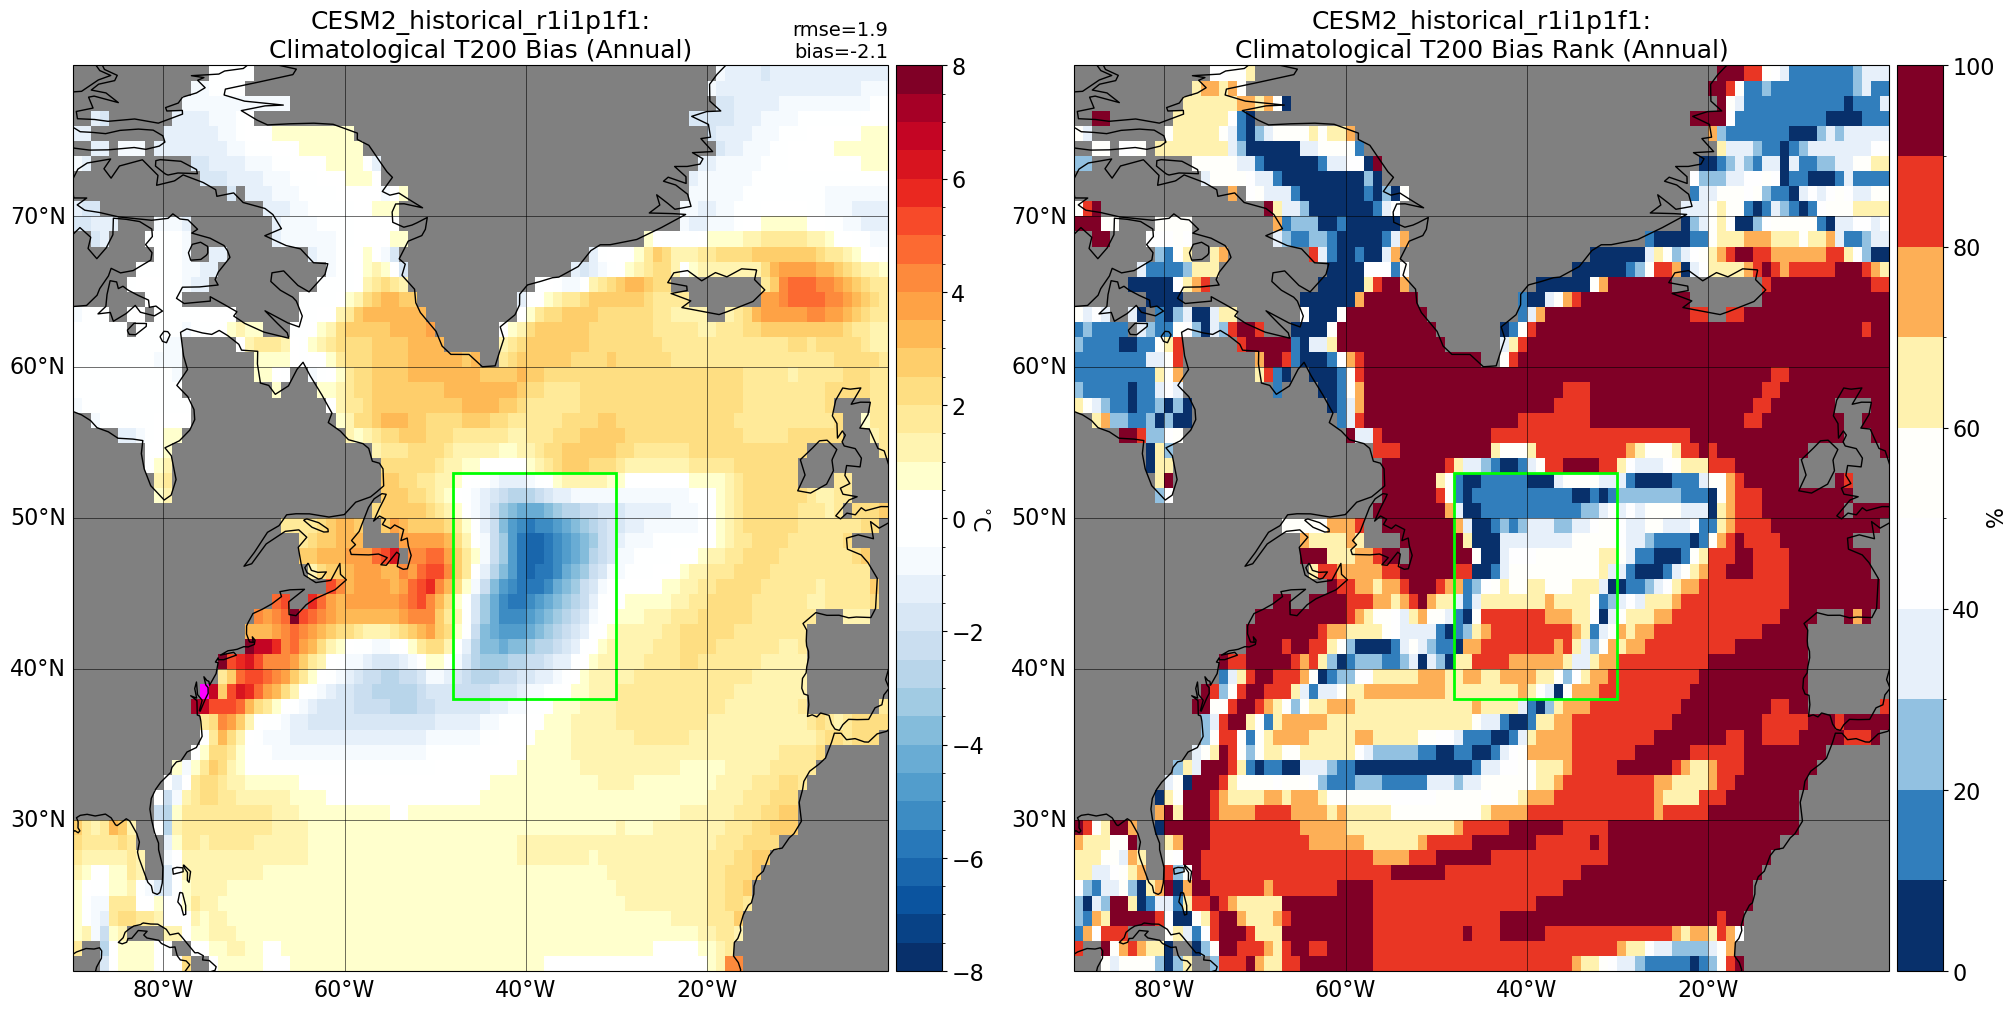

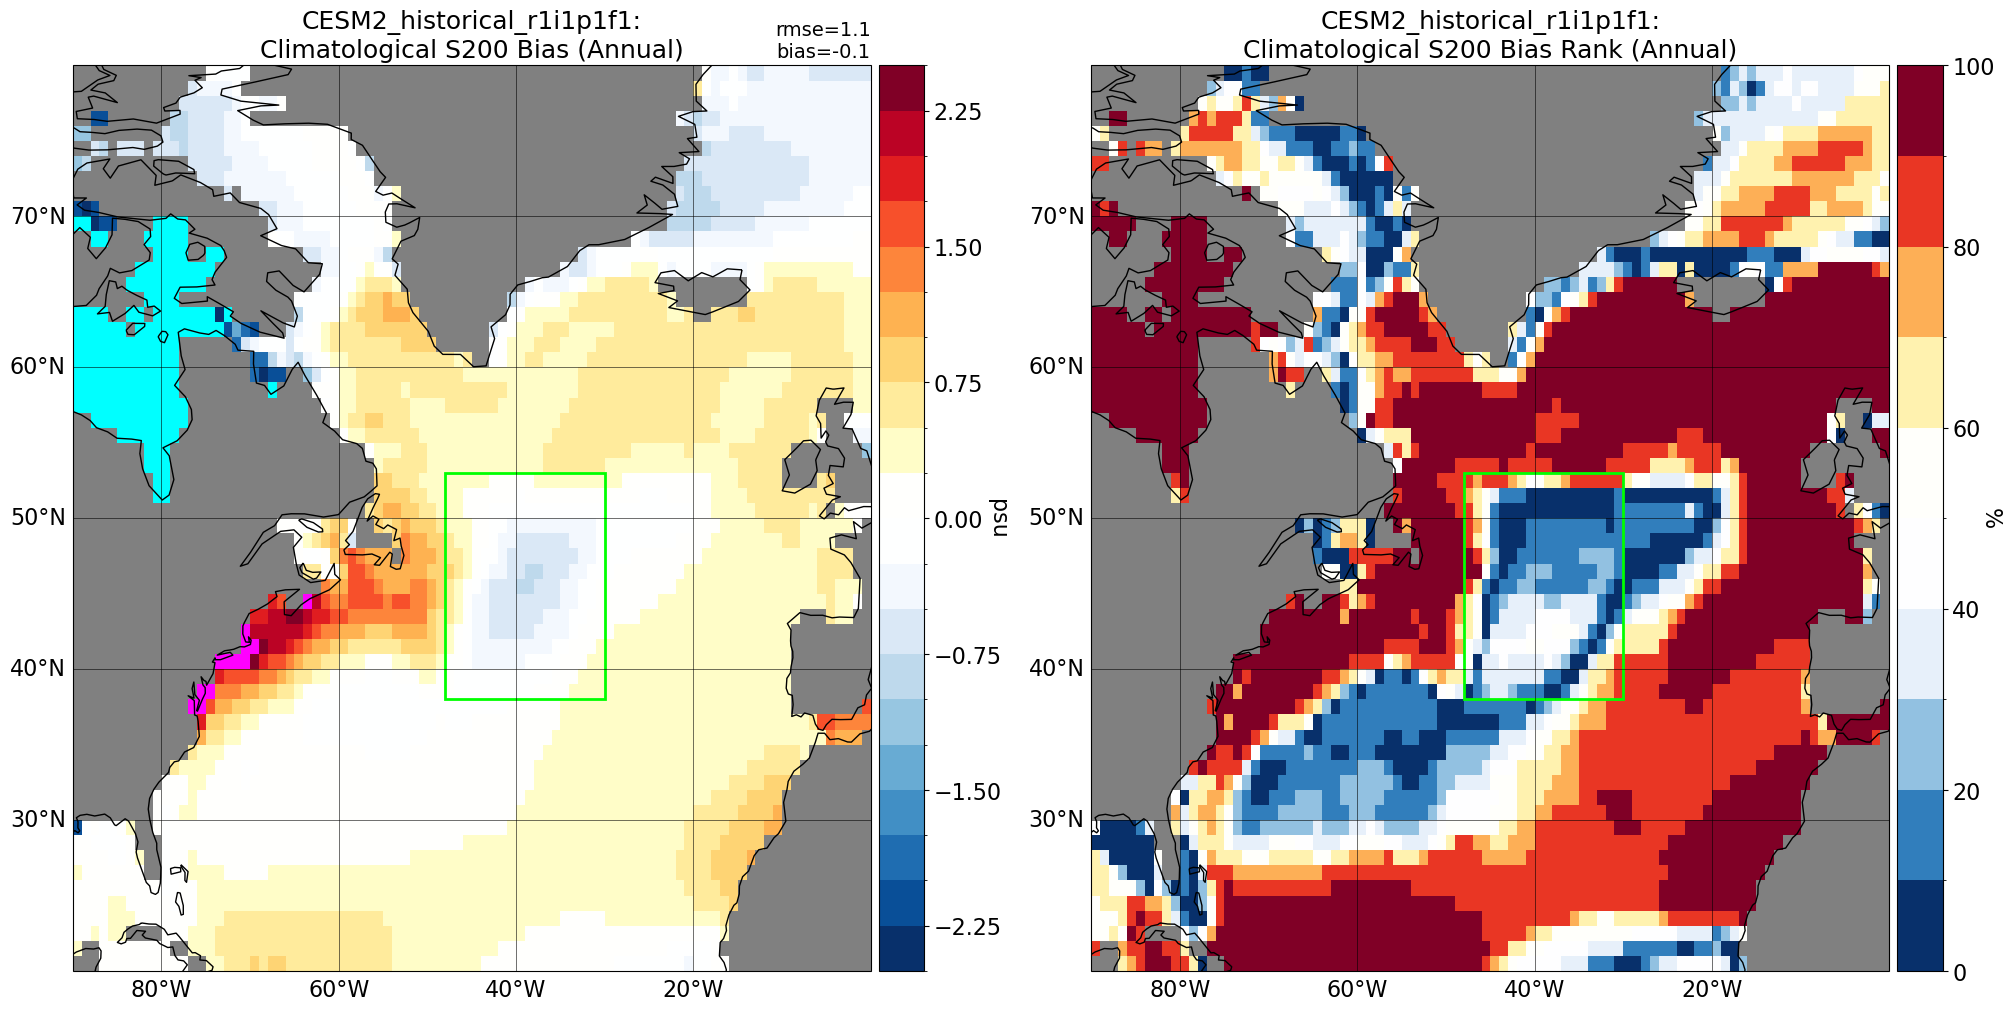

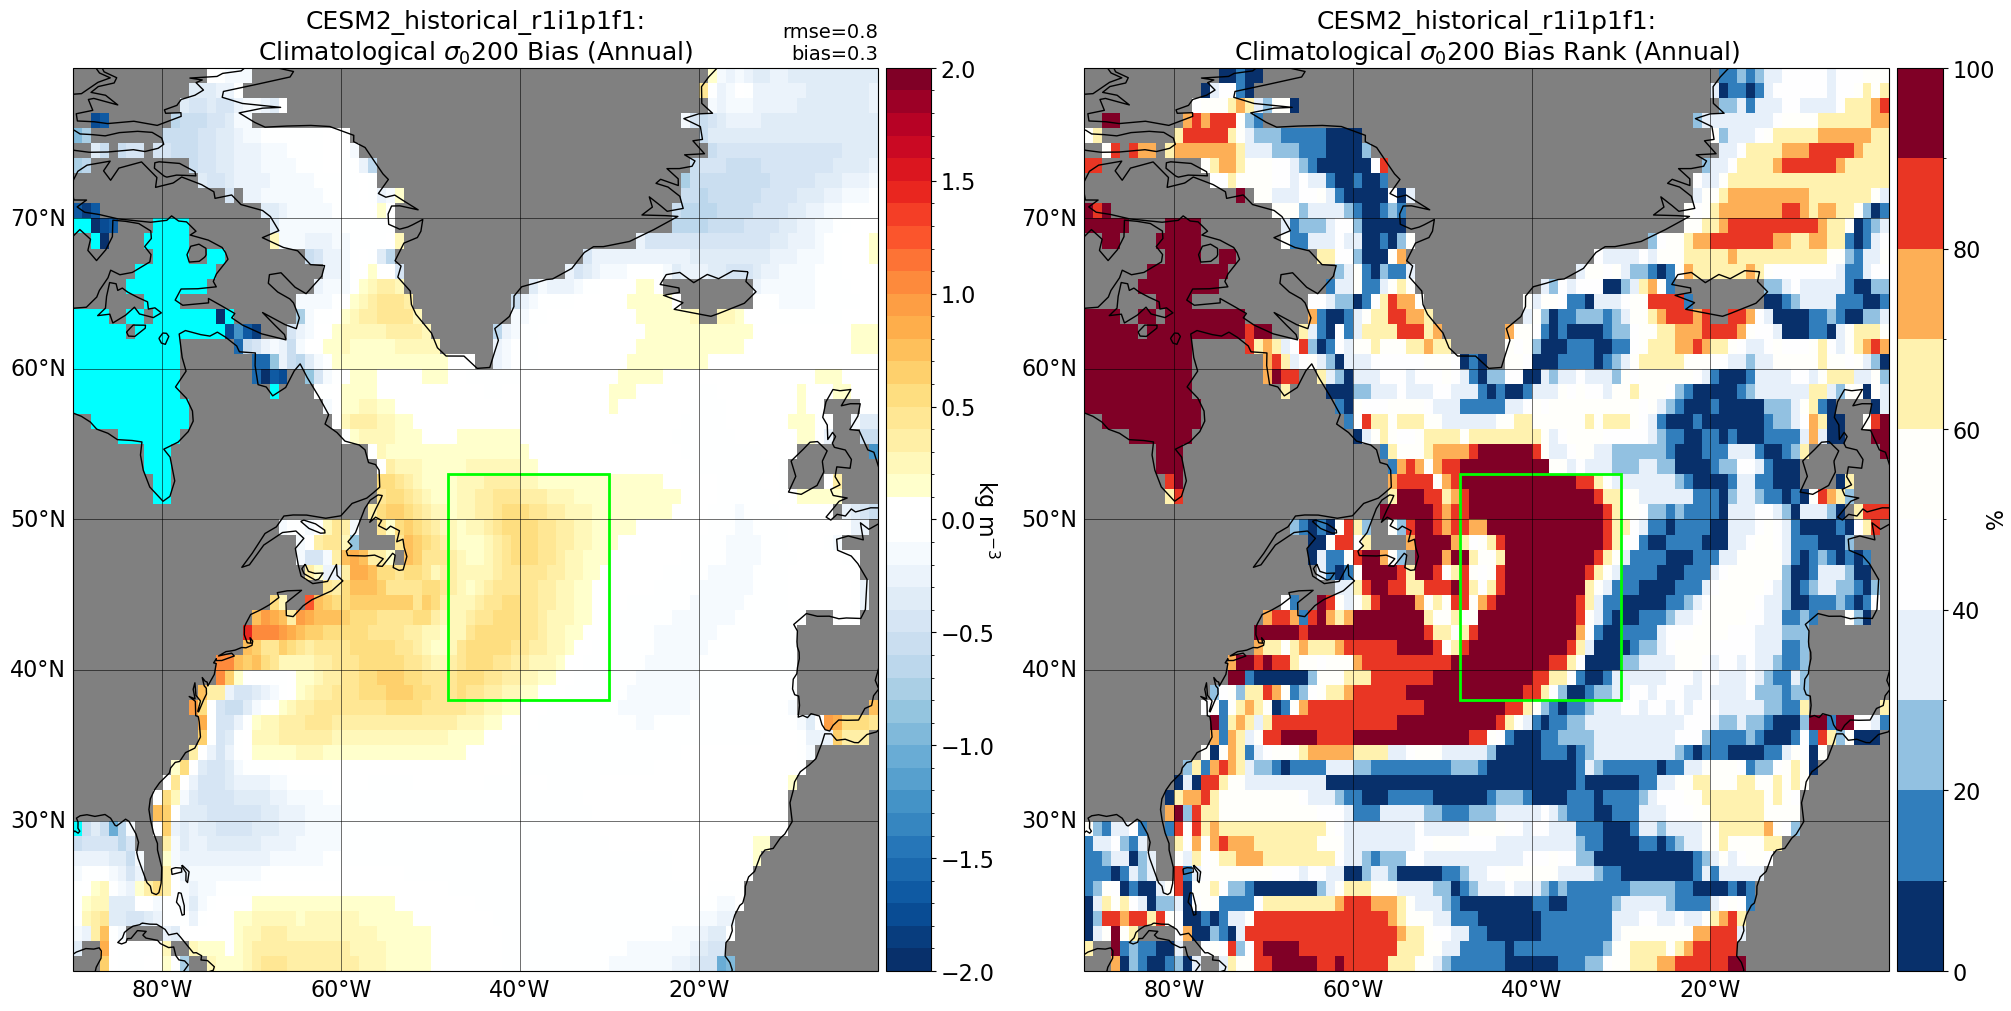

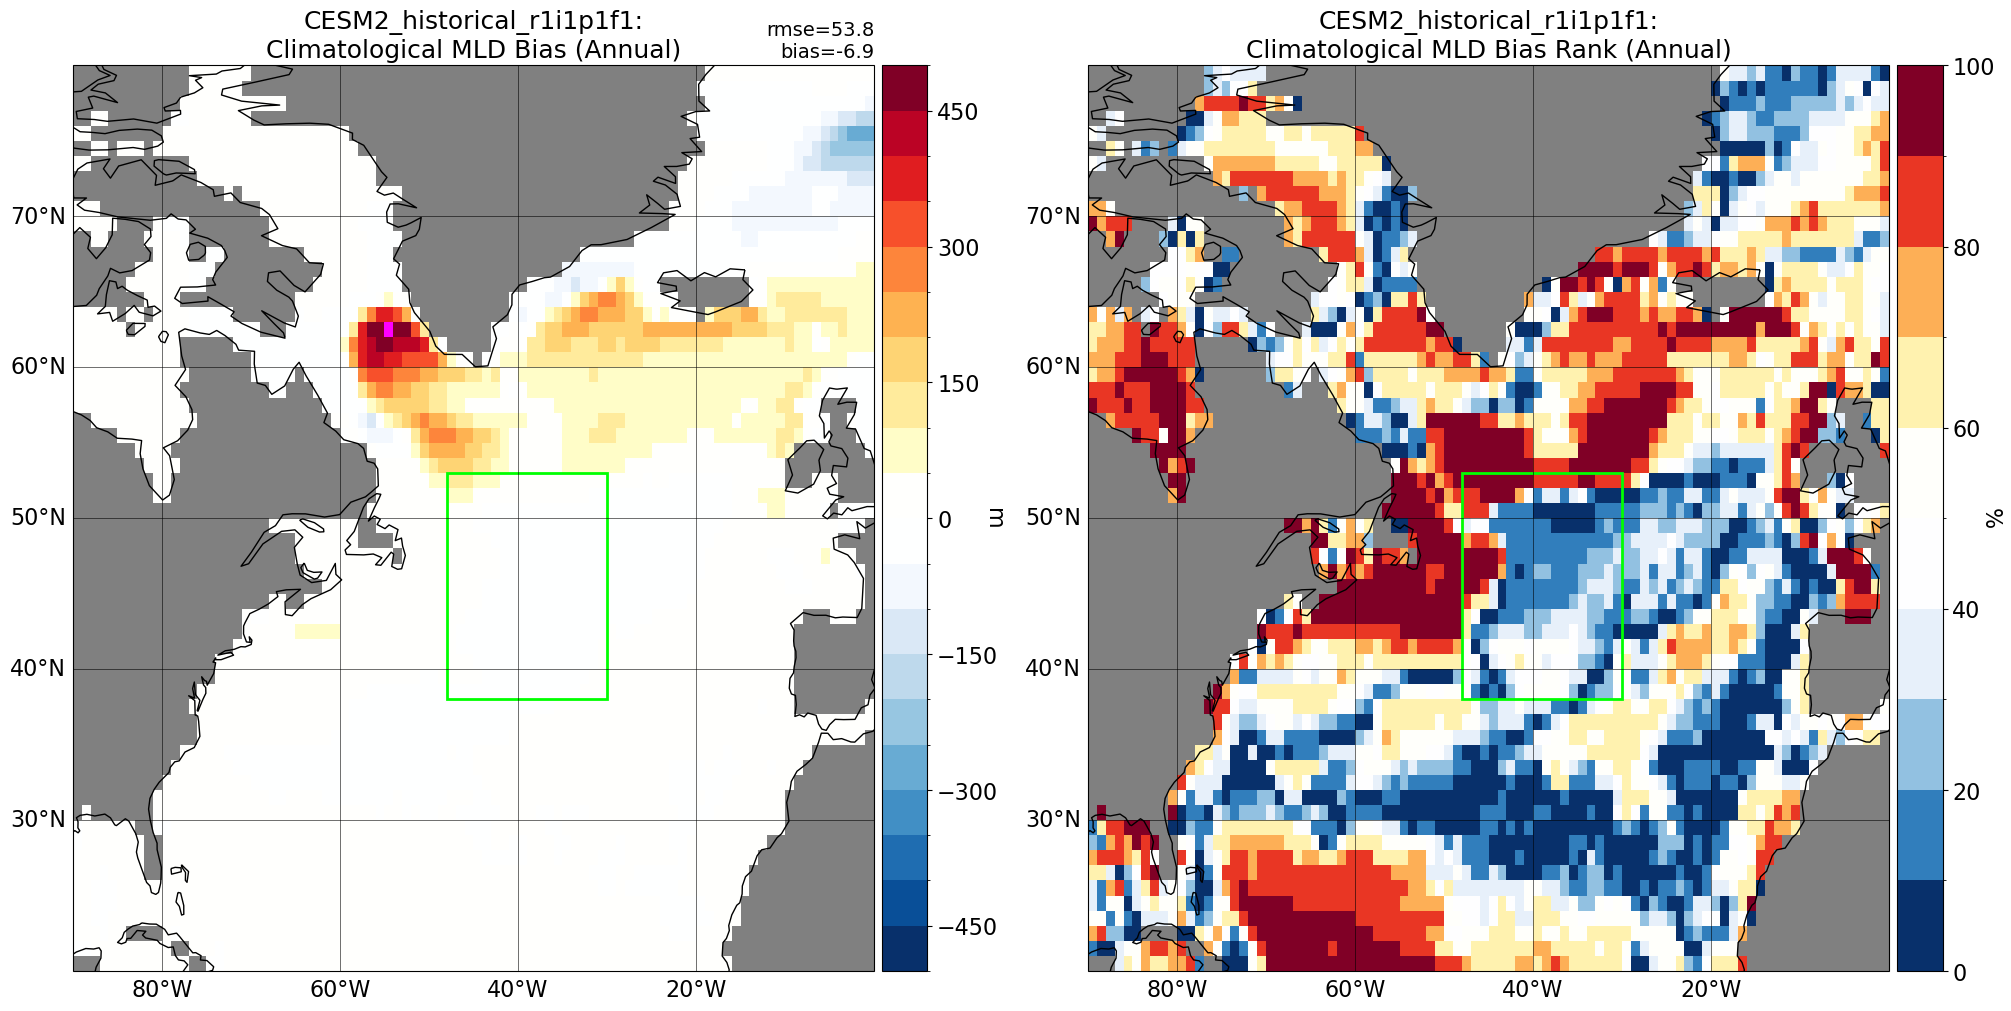

In [72]:
outmod_dir = os.path.join(os.environ['WORK_DIR'], 'model')
Path(outmod_dir).mkdir(parents=True, exist_ok=True)

region = opts['plot_region']
focus  = opts['focus_region']
month  = opts['plot_month']

ds_t200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'thetao_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=False, savedir=outmod_dir)
ds_s200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'so_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=False, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'sigma0_zavg',
                                 region=region, focus_region=focus, month=month,
                                 save=False, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'mld',
                                 region=region, focus_region=focus, month=month,
                                 save=False, savedir=outmod_dir)

### Scatter plot of θ vs S biases

Compact summary of where θ and S biases are large together.

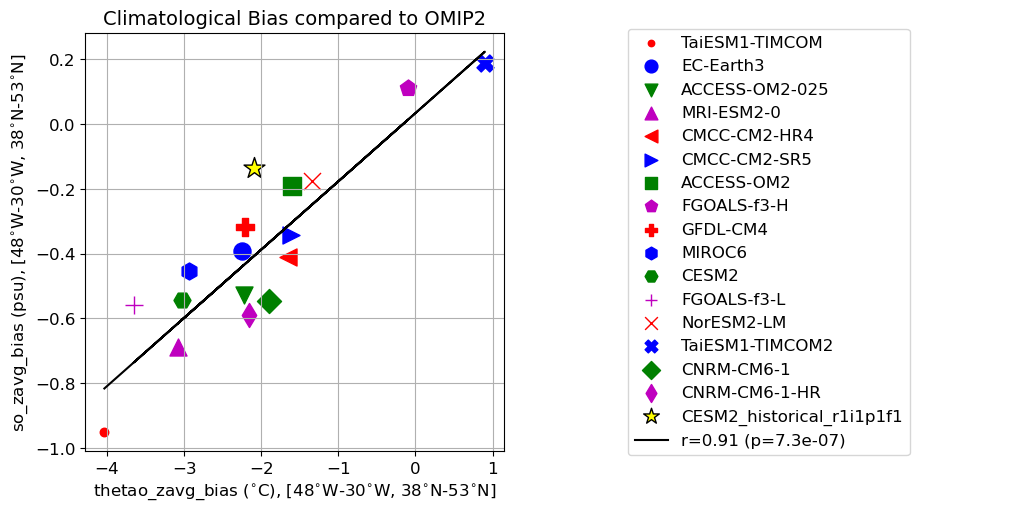

In [73]:
POD_utils.ScatterPlot_Error(
    ds_t200, 'thetao_zavg_bias',
    ds_s200, 'so_zavg_bias',
    model_name,
    save=False, savedir=outmod_dir,
)

### WMT lines vs OMIP benchmarks (by region)

Compare modeled surface-forced WMT against observation-based decomposed benchmarks (`obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc`).

WMT benchmark vars: ['heat', 'wmt', 'freshwater']


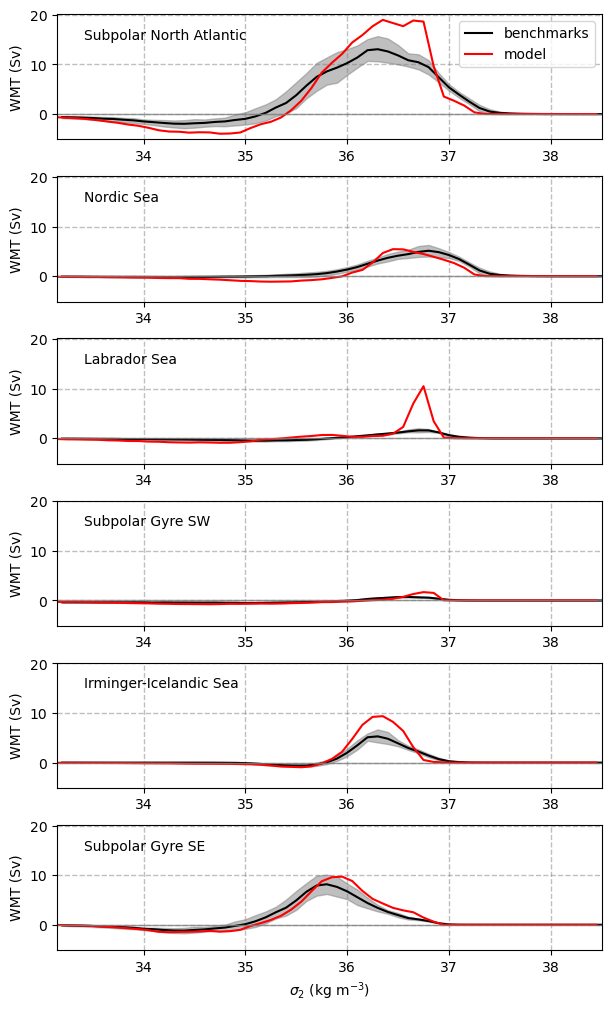

In [74]:
ds_wmt_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc')
)
print('WMT benchmark vars:', list(ds_wmt_benchmarks.data_vars))

POD_utils.wmt_plot_byregion(
    ds_wmt_benchmarks, ds_wmt_lines, sigma_classes,
    save=False, savedir=outmod_dir,
)

### Density-flux maps at specified σ₂ classes

Maps of surface density flux into each water-mass class compared to observation-based decomposed benchmarks (`obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc`).

density-flux benchmark vars: ['heat', 'salt', 'wmt', 'wmt_freq']


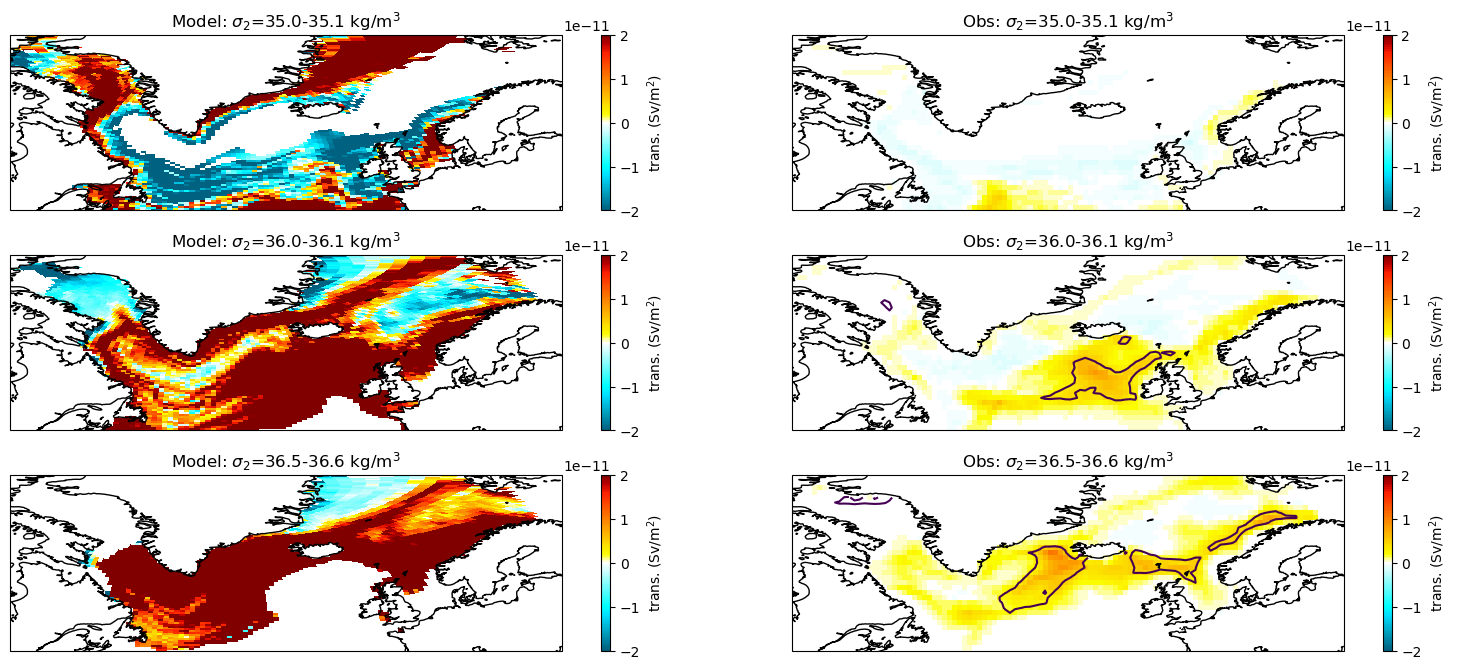

In [76]:
ds_dflux_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc')
)
print('density-flux benchmark vars:', list(ds_dflux_benchmarks.data_vars))

POD_utils.wmt_plot_maps(
    ds_dflux_benchmarks, ds_wmt_maps,
    ['time', 'x', 'y'],
    sigma_classes,
    save=False, savedir=outmod_dir,
)

- Check density contour for model
- fix plotting error

### Atlantic AMOC streamfunction (σ₂ space)

Time-mean of Atlantic basin MOC (`region=1`, set by `basinmask` in `POD_utils.calculate_moc`) plotted as lat × σ₂. Positive (red) shows northward upper-cell flow; negative (blue) shows the southward deep cell. The typical CESM2 AMOC pattern is a positive cell at σ₂ < ~36.5 kg/m³ and a return cell below.

moc_atl dims:  {'sigma': 95, 'lat': 179}
moc_atl range: -4.264 to +26.323 Sv
sigma range:   26.10 to 37.97 kg/m^3
lat range:     -88.5 to 89.5
NaN fraction:  0.0%


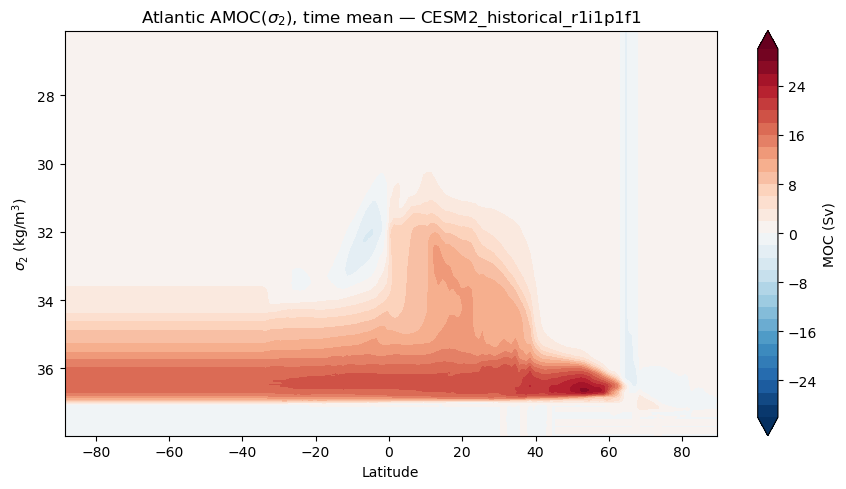

Atlantic upper-cell max MOC: 24.99 Sv (expect ~10-25 Sv for CESM2)


In [77]:
# Atlantic AMOC(sigma2) — time mean
import matplotlib.pyplot as plt

# region=1 is Atlantic+Arctic per basinmask attrs; take time mean and
# materialize (.compute) so matplotlib's contourf gets concrete values.
# Force dim order to (sigma, lat) so contourf gets z.shape == (len(y), len(x))
# regardless of the internal dim order calculate_moc produces.
moc_atl = ds_moc['MOC'].isel(region=1).mean('time').transpose('sigma', 'lat')

# sigma2_grid_96L anchors the lowest sigma_edge to 0 (a placeholder for
# "lighter than any physical seawater"). That anchor stretches the y-axis from
# 0 to 38 if left in, compressing the meaningful 26-38 range into a thin band
# and making the plot look empty. Slice to the physical range before plotting.
moc_atl = moc_atl.sel(sigma=slice(26, 38)).compute()

# Diagnostic prints: tell us whether the computation produced real values
print(f'moc_atl dims:  {dict(moc_atl.sizes)}')
print(f'moc_atl range: {float(moc_atl.min()):+.3f} to {float(moc_atl.max()):+.3f} Sv')
print(f'sigma range:   {float(moc_atl.sigma.min()):.2f} to {float(moc_atl.sigma.max()):.2f} kg/m^3')
print(f'lat range:     {float(moc_atl.lat.min()):.1f} to {float(moc_atl.lat.max()):.1f}')
print(f'NaN fraction:  {float(moc_atl.isnull().mean()):.1%}')

fig, ax = plt.subplots(figsize=(9, 5))
levels = np.arange(-30, 31, 2)  # Sv contours, 2 Sv spacing
cf = ax.contourf(
    moc_atl['lat'], moc_atl['sigma'], moc_atl,
    levels=levels, cmap='RdBu_r', extend='both',
)
ax.invert_yaxis()  # heavier water (larger sigma) downward visually
ax.set_xlabel('Latitude')
ax.set_ylabel(r'$\sigma_2$ (kg/m$^3$)')
ax.set_title(f'Atlantic AMOC($\sigma_2$), time mean — {model_name}')
fig.colorbar(cf, ax=ax, label='MOC (Sv)')
plt.tight_layout()
plt.show()

# Quick numeric sanity: AMOC max in upper cell should be O(10-25) Sv for CESM2
upper_cell_max = float(moc_atl.where(moc_atl['sigma'] < 36.5).max())
print(f'Atlantic upper-cell max MOC: {upper_cell_max:.2f} Sv (expect ~10-25 Sv for CESM2)')

### WMT + AMOC at 45°N (compensation diagnostic)

Three curves as functions of σ₂ for the Subpolar North Atlantic:

- **Obs WMT** mean across 8 benchmarks (black line) with the min/max spread shaded
- **Model WMT** integrated over the full SPNA (red line)
- **Model AMOC at 45°N** (blue line, time mean)

In steady state, mass conservation implies the AMOC streamfunction at 45°N approximately balances the surface-forced WMT integrated north of 45°N. Departures suggest model deficiencies in surface forcing, mixed-layer dynamics, or interior mixing.

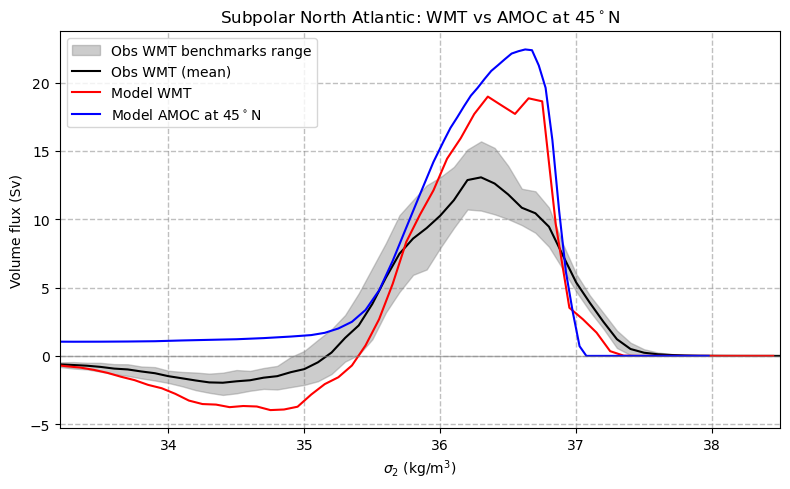

In [79]:
# WMT + AMOC at 45N compensation diagnostic
POD_utils.wmt_amoc_plot(
    ds_wmt_benchmarks, ds_wmt_lines, ds_moc,
    lat_target=45,
    region_name='Subpolar North Atlantic',
    save=False, savedir=outmod_dir,
)

### Risks / fallbacks

**Bias-plot path (Section 4 first half):**
- **`POD_utils.preprocess_coords`** may rename `nlat`/`nlon` to other names. If downstream   code errors after Step 1, fall back to `ds_target = ds_bias.copy()` (skip the preprocess call).
- **`compute_zavg`** requires `dz` to have `lev` in meters and broadcast against the variable.   If `*_zavg` arrays come back with NaNs or wrong shape, recheck the cm→m conversion and   `dz.assign_coords(lev=...)`.
- **`SpatialPlot_climo_bias`** expects `ds_model` to carry variables named `thetao_zavg`,   `so_zavg`, `sigma0_zavg`, `mld`. The OMIP file's actual var names may differ — inspect   `ds_model.data_vars` after loading and rename with `ds_model = ds_model.rename({...})` if needed.
- **`ScatterPlot_Error`** assumes the bias dataset returned by `SpatialPlot_climo_bias` contains   the `*_bias` fields. If it errors, inspect `ds_t200.data_vars` after the first plot and adjust.

**WMT path (Section 3 Steps 6–7 + Section 4 second half):**
- **xwmt version pin**: `POD_utils.calc_wmt` calls `xwmt.swmt(...)` — that class only exists   in xwmt 0.0.3. xwmt ≥ 0.1.0 replaced it with `WaterMassTransformations`, which has a different   signature. The esnb env is pinned to xwmt 0.0.3 for this reason.
- **Surface-fields shape**: Step 6 builds `ds_target_wmt` independently of the bias-path   `ds_target` (which has been regridded + climatology'd). WMT needs the native-grid time series,   not the climatology.
- **`wmt_plot_maps` dim names**: the third arg expects `[time_coord, lon_coord, lat_coord]`   matching the result of `compute_wmt(..., 'MAPS')`. We pass `['time', 'x', 'y']` since `wmt_preproc`   renames spatial dims. If it errors, inspect `ds_wmt_maps.dims` and adjust the list.
- **xwmt `vsf` handling**: `wmt_preproc` converts `vsf` to `wfo` (the CMIP wfo would have the   opposite sign convention). We feed `vsf` so this branch is exercised.